# Car Color Detection using YOLOv3

Goal:
Detect vehicles in images and determine the dominant color
of each detected vehicle.

Dataset:
Images containing vehicles from COCO dataset / custom dataset.

Classes used:
car, bus, truck

In [24]:
!pip install opencv-python numpy matplotlib

In [25]:
!git clone https://github.com/palak2564/datascience_projects.git
%cd datascience_projects/car_color_detection

Cloning into 'datascience_projects'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 40 (delta 3), reused 35 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 52.91 KiB | 752.00 KiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/datascience_projects/car_color_detection/datascience_projects/car_color_detection


In [26]:
!sed -n '1,200p' enhanced_detector.py

"""
Car Color Detection System - Enhanced Version
This version includes improved color detection using K-means clustering
"""

import cv2
import numpy as np
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
import os
from sklearn.cluster import KMeans


class ImprovedCarColorDetector:
    """Enhanced car color detector with better color identification"""
    
    def __init__(self):
        # Box colors for different detections
        self.blue_car_box_color = (0, 0, 255)  # Red box for blue cars
        self.other_car_box_color = (255, 0, 0)  # Blue box for other cars
        self.person_box_color = (0, 255, 0)  # Green box for people
        
        # Detection settings
        self.minimum_confidence = 0.5
        self.overlap_threshold = 0.3
        
        # Model variables
        self.neural_network = None
        self.object_classes = []
        
        # Color definitions in BGR
        self.color_ranges = {
            'blue': 

In [27]:
from enhanced_detector import ImprovedCarColorDetector

detector = ImprovedCarColorDetector()

In [28]:
!pip install opencv-python scikit-learn matplotlib

In [29]:
!wget https://pjreddie.com/media/files/yolov3.weights

--2026-03-10 13:48:27--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3030::ac43:b9c7, ...
Connecting to pjreddie.com (pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-03-10 13:48:28--  https://data.pjreddie.com/files/yolov3.weights
Resolving data.pjreddie.com (data.pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3030::ac43:b9c7, ...
Connecting to data.pjreddie.com (data.pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  83.3MB/s    in 2.8s    

2026-03-10 13:48:31 (83.3 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]



In [30]:
model_loaded = detector.setup_model(
    "yolov3.cfg",
    "yolov3.weights",
    "coco.names"
)

print("Model loaded:", model_loaded)

Model loaded: True


In [42]:
from google.colab import files
uploaded = files.upload()

Saving traffic-jam-getty.webp to traffic-jam-getty.webp


In [43]:
import cv2

image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path)

print("Image loaded:", image.shape)

Image loaded: (684, 1025, 3)


In [44]:
boxes, confidences, classes, indices = detector.detect_vehicles_and_people(image)

print("Detections found:", len(indices))

Detections found: 62


In [45]:
result_image = detector.annotate_image_with_detections(
    image,
    boxes,
    confidences,
    classes,
    indices
)

In [46]:
print(type(result_image))

<class 'tuple'>


In [47]:
print(result_image)

(array([[[156, 158, 153],
        [153, 154, 149],
        [149, 151, 146],
        ...,
        [ 75, 118, 134],
        [ 33,  61,  93],
        [ 19,  25,  76]],

       [[153, 154, 149],
        [151, 153, 148],
        [150, 152, 147],
        ...,
        [ 80, 122, 138],
        [ 41,  67,  97],
        [ 24,  30,  79]],

       [[149, 151, 146],
        [150, 152, 147],
        [151, 153, 148],
        ...,
        [ 80, 118, 135],
        [ 40,  62,  93],
        [ 26,  31,  78]],

       ...,

       [[ 73,  71,  62],
        [ 73,  71,  62],
        [ 73,  71,  62],
        ...,
        [ 33,  35,  28],
        [ 33,  35,  28],
        [ 33,  35,  28]],

       [[ 73,  72,  61],
        [ 73,  72,  61],
        [ 73,  72,  61],
        ...,
        [ 33,  36,  26],
        [ 33,  36,  26],
        [ 33,  36,  26]],

       [[ 73,  72,  61],
        [ 73,  72,  61],
        [ 73,  72,  61],
        ...,
        [ 33,  36,  26],
        [ 33,  36,  26],
        [ 33,  36,  26]

In [48]:
result_image, total_vehicles, blue_vehicles, other_vehicles = detector.annotate_image_with_detections(
    image,
    boxes,
    confidences,
    classes,
    indices
)

Text(0.5, 1.0, 'Vehicle Detection and Color Classification')

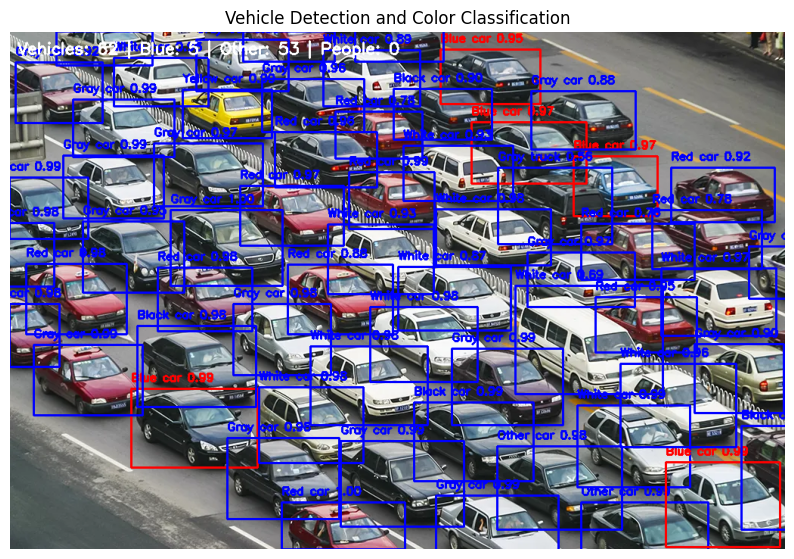

In [49]:
import cv2
import matplotlib.pyplot as plt

result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(result_rgb)
plt.axis("off")
plt.title("Vehicle Detection and Color Classification")